# Carpturar Foto con el Telefono

--- Cámara iniciada con el índice: 2 ---
Mostrando vista previa durante 5 segundos...
¡Foto guardada en: c:\Users\Infosat\Documents\SIS420-IA\Laboratorios\SIS420-IA\Billetes_Proyecto\principal\Fotos_Capturadas\foto_1764292535.jpg!


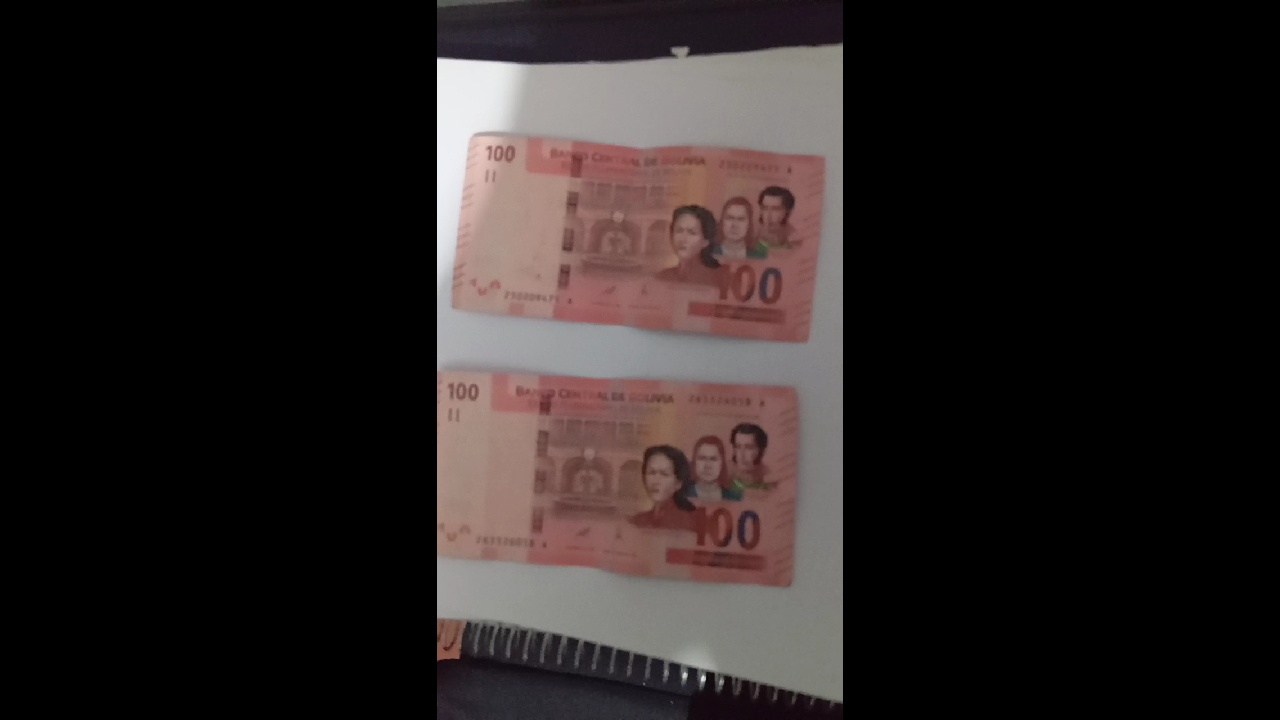

Programa finalizado.


In [22]:
import cv2
import os
import time
from IPython.display import display, Image # Importaciones útiles en un notebook

# 1. Configuración de la carpeta de destino
nombre_carpeta = "Fotos_Capturadas"
ruta_completa = os.path.join(os.getcwd(), nombre_carpeta)

if not os.path.exists(ruta_completa):
    os.makedirs(ruta_completa)
    print(f"Carpeta creada: {ruta_completa}")

# 2. Iniciar la cámara (¡MODIFICA ESTA LÍNEA!)
# --- CAMBIA ESTE NÚMERO Y VUELVE A EJECUTAR ---
INDICE_CELULAR = 2 
# ----------------------------------------------
cap = cv2.VideoCapture(INDICE_CELULAR) 

# Verificar si la cámara se abrió correctamente
if not cap.isOpened():
    print(f"--- ERROR CRÍTICO: No se pudo abrir la cámara con el índice {INDICE_CELULAR}. ---")
    print("Prueba cambiando INDICE_CELULAR a otro valor (0, 1, 2, 3, etc.)")
    exit()

# Opcional: Establecer resolución
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

print(f"--- Cámara iniciada con el índice: {INDICE_CELULAR} ---")
print("Mostrando vista previa durante 5 segundos...")

# Guardar el tiempo inicial
tiempo_inicio = time.time()
TIEMPO_ESPERA = 5 # Segundos

# Variables para gestionar la ventana de OpenCV
ventana_abierta = False

while True:
    ret, frame = cap.read()
    
    if not ret:
        print("Error al leer el frame. Conexión perdida.")
        break

    # Mostrar la imagen en una ventana
    cv2.imshow('Vista Previa - Celular USB (Se cierra en 5 segundos)', frame)
    ventana_abierta = True

    # Verificar si han pasado 5 segundos
    if time.time() - tiempo_inicio >= TIEMPO_ESPERA:
        nombre_foto = f"foto_{int(time.time())}.jpg"
        ruta_archivo = os.path.join(ruta_completa, nombre_foto)
        
        cv2.imwrite(ruta_archivo, frame)
        print(f"¡Foto guardada en: {ruta_archivo}!")
        display(Image(ruta_archivo))
        
        break # Salir del bucle

    cv2.waitKey(1)

# Liberar la cámara y cerrar ventanas
cap.release()
if ventana_abierta:
    cv2.destroyAllWindows()
    
print("Programa finalizado.")

# 1. reconocer billetes

Este reconocimieto de yolo funciona sin camara, puede tomar una imagen estaria ejemplo imagen01.png, imagen03.png, imagen03.png,

In [ ]:
# Celda 1: Detección y Recorte con YOLO (este se puede tuilizar para imagenes estaticas de prueba)

import cv2
import os
from ultralytics import YOLO

# Cargar modelo YOLO
model = YOLO("my_model.pt")

# Crear carpeta de salida si no existe 
os.makedirs("detecciones", exist_ok=True) 

# Leer imagen
img = cv2.imread("imagen03.png")

# Detectar objetos
results = model(img)

# Iterar sobre detecciones
for i, box in enumerate(results[0].boxes):
    # Coordenadas del bounding box
    x1, y1, x2, y2 = box.xyxy[0].int().tolist()
    
    # Recortar objeto
    objeto = img[y1:y2, x1:x2]

    # Guardar en carpeta 'detecciones' usando solo el índice como nombre de archivo
    # (e.g., detecciones/0.jpg, detecciones/1.jpg, etc.)
    cv2.imwrite(f"detecciones/imagen{i:03d}.jpg", objeto)

print("Objetos recortados y guardados en la carpeta 'detecciones'.")


0: 640x640 1 100_cien, 1 200_doscientos, 1 20_veinte, 71.4ms
Speed: 30.3ms preprocess, 71.4ms inference, 7.1ms postprocess per image at shape (1, 3, 640, 640)
Objetos recortados y guardados en la carpeta 'detecciones'.


Este se se utilizar para el tomar la foto con la camara del telefono, se requiere que se tenga DroidCam en la PC y el Telefono y esta conectados por Wifi o USB

In [ ]:
# Celda 1: Detección y Recorte con YOLO

import cv2
import os
from ultralytics import YOLO

# Cargar modelo YOLO
model = YOLO("my_model.pt")

# Crear carpeta de salida si no existe 
os.makedirs("detecciones", exist_ok=True) 

# --- ÚNICO CAMBIO: Reemplazar la lectura estática por un bucle de carpeta ---
carpeta_entrada = "Fotos_Capturadas"
archivos = [f for f in os.listdir(carpeta_entrada) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

for nombre_archivo_imagen in archivos:
    ruta_imagen_completa = os.path.join(carpeta_entrada, nombre_archivo_imagen)
    
    # Leer imagen
    img = cv2.imread(ruta_imagen_completa)
    
    if img is None:
        continue # Si la imagen no se carga, saltamos a la siguiente.

    # Detectar objetos
    results = model(img)

    # Iterar sobre detecciones
    for i, box in enumerate(results[0].boxes):
        # Coordenadas del bounding box
        x1, y1, x2, y2 = box.xyxy[0].int().tolist()
        
        # Recortar objeto
        objeto = img[y1:y2, x1:x2]

        # Guardar en carpeta 'detecciones' usando solo el índice 'i'
        # ADVERTENCIA: Esto SOBREESCRIBIRÁ archivos si múltiples imágenes tienen objetos detectados.
        # (e.g., detecciones/imagen000.jpg se reescribirá por cada objeto detectado en la misma posición 'i').
        cv2.imwrite(f"detecciones/imagen{i:03d}.jpg", objeto)

print("Objetos recortados y guardados en la carpeta 'detecciones'.")


0: 384x640 2 100_ciens, 40.2ms
Speed: 3.8ms preprocess, 40.2ms inference, 4.9ms postprocess per image at shape (1, 3, 384, 640)
Objetos recortados y guardados en la carpeta 'detecciones'.


# muestra los billetes

Se encontraron 2 billetes detectados para mostrar.


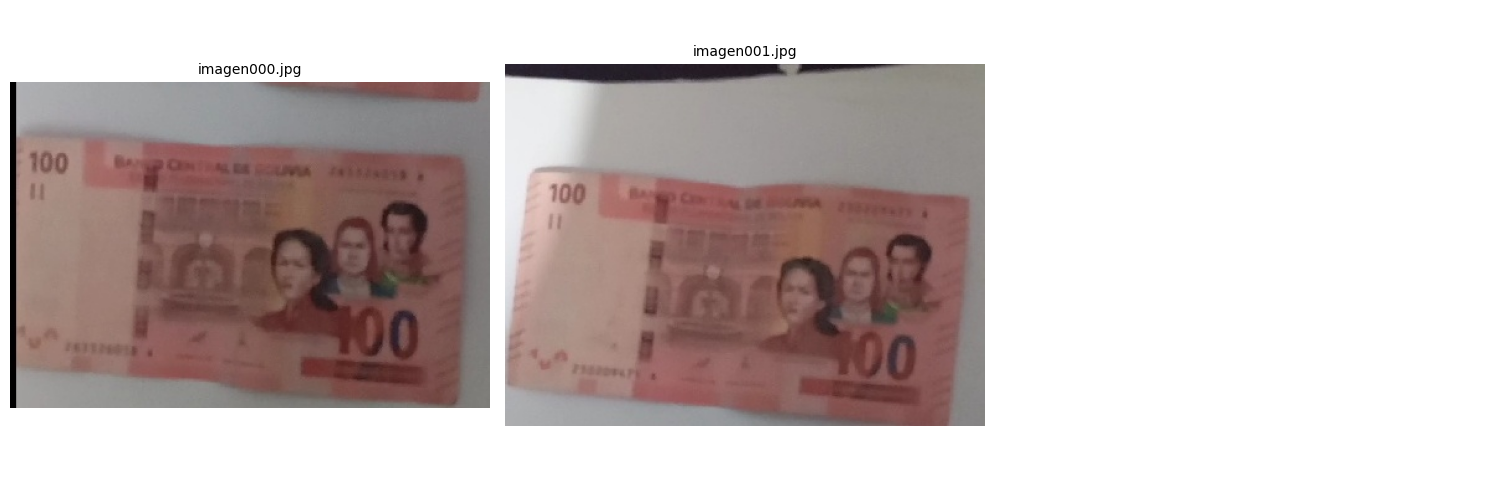

In [26]:
# Celda 3: Visualización de las Detecciones

import cv2
import os
import matplotlib.pyplot as plt

# Directorio de las imágenes recortadas generadas por YOLO
directorio_recortes = "detecciones"

# Obtener la lista de archivos de imagen en el directorio
archivos_recortes = [f for f in os.listdir(directorio_recortes) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Ordenar los archivos por nombre (ej. imagen000.jpg, imagen001.jpg)
archivos_recortes.sort()

# Calcular el número de billetes detectados
num_detecciones = len(archivos_recortes)

if num_detecciones == 0:
    print("No se encontraron imágenes en la carpeta 'detecciones'. Ejecuta la Celda 1 primero.")
else:
    print(f"Se encontraron {num_detecciones} billetes detectados para mostrar.")
    
    # Determinar el layout para la galería
    # Usaremos 3 columnas como máximo para que se vean bien
    ncols = 3 
    # Calcular el número de filas necesario
    nrows = (num_detecciones + ncols - 1) // ncols

    # Crear la figura y los subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
    
    # Aplanar el array de axes para facilitar la iteración si es necesario, 
    # o si solo hay una fila/columna, usar la estructura simple.
    if num_detecciones == 1:
        axes = [axes] # Asegura que sea iterable incluso para 1 imagen
    elif nrows > 1 and ncols > 1:
        axes = axes.flatten()

    # Iterar sobre cada archivo y mostrarlo
    for i, nombre_archivo in enumerate(archivos_recortes):
        ruta_completa = os.path.join(directorio_recortes, nombre_archivo)
        
        # Cargar la imagen usando OpenCV
        img_recorte = cv2.imread(ruta_completa)
        
        # OpenCV lee imágenes en formato BGR. Matplotlib espera RGB. 
        # Es necesario convertir el color para mostrarlo correctamente.
        img_rgb = cv2.cvtColor(img_recorte, cv2.COLOR_BGR2RGB)
        
        # Seleccionar el subplot actual
        ax = axes[i]
        
        # Mostrar la imagen
        ax.imshow(img_rgb)
        
        # Establecer título
        ax.set_title(nombre_archivo, fontsize=10)
        
        # Ocultar los ejes (ticks y etiquetas) para una vista más limpia
        ax.axis('off')

    # Ocultar subplots vacíos si el número de detecciones no llena la última fila
    for j in range(num_detecciones, nrows * ncols):
        if j < len(axes):
            axes[j].axis('off')

    # Ajustar el diseño para evitar la superposición
    plt.tight_layout()
    # Mostrar la figura
    plt.show()

# 2. convertir a 64x64

In [ ]:
#########################################
import cv2
import os
import numpy as np # Necesitamos NumPy para definir el color de relleno

# Carpeta de entrada y salida
input_folder = "detecciones"
output_folder = "imagenes_64x64"
TARGET_SIZE = 64 # Nuevo tamaño objetivo

# Crear carpeta de salida si no existe
os.makedirs(output_folder, exist_ok=True)

# Iterar sobre todas las imágenes en la carpeta de entrada
for filename in os.listdir(input_folder):
    # Filtrar solo archivos de imagen
    if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        
        img_path = os.path.join(input_folder, filename)
        img = cv2.imread(img_path)

        if img is None:
            print(f"No se pudo leer {filename}, se omite.")
            continue

        # --- Lógica de Redimensionamiento sin Distorsión ---
        
        # 1. Obtener dimensiones originales
        H, W, _ = img.shape
        
        # 2. Calcular factor de escala para el lado más largo
        if H > W:
            scale = TARGET_SIZE / H
            new_H = TARGET_SIZE
            new_W = int(W * scale)
        else:
            # Si W > H o si W == H, escalar basado en W
            scale = TARGET_SIZE / W
            new_W = TARGET_SIZE
            new_H = int(H * scale)

        # 3. Redimensionar manteniendo la proporción (Aspect Ratio)
        resized_ratio = cv2.resize(img, (new_W, new_H), interpolation=cv2.INTER_AREA)

        # 4. Calcular el relleno (padding) necesario
        delta_w = TARGET_SIZE - new_W
        delta_h = TARGET_SIZE - new_H
        
        # Dividir el relleno en la parte superior/inferior e izquierda/derecha
        top = delta_h // 2
        bottom = delta_h - top
        left = delta_w // 2
        right = delta_w - left

        # 5. Aplicar el relleno (padding) para obtener un cuadrado 64x64
        # El valor [0, 0, 0] es el color negro (BGR en OpenCV)
        color = [0, 0, 0] 
        final_img = cv2.copyMakeBorder(resized_ratio, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)

        # --- Fin de la Lógica de Redimensionamiento ---

        # Guardar en carpeta de salida
        output_path = os.path.join(output_folder, filename)
        cv2.imwrite(output_path, final_img) # Guardamos la imagen final con padding

        print(f"✅ Convertida sin distorsión: {filename} → {output_path}")

print("Todas las imágenes han sido convertidas a 64x64 sin distorsión.")

✅ Convertida sin distorsión: imagen000.jpg → imagenes_64x64\imagen000.jpg
✅ Convertida sin distorsión: imagen001.jpg → imagenes_64x64\imagen001.jpg
Todas las imágenes han sido convertidas a 64x64 sin distorsión.


✅ Mostrando 2 imágenes a 64x64:


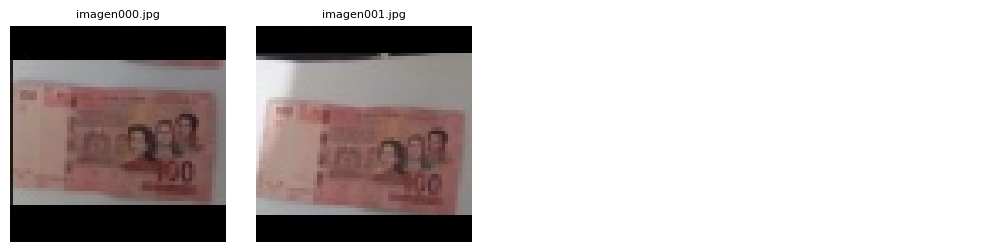

In [1]:
# Celda para visualizar todas las imágenes en la carpeta 'imagenes_64x64'

import cv2
import os
import matplotlib.pyplot as plt

# Directorio de las imágenes redimensionadas
directorio_64x64 = "imagenes_64x64"

# Obtener la lista de archivos de imagen y ordenarlos
archivos_64x64 = [f for f in os.listdir(directorio_64x64) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
archivos_64x64.sort()

num_imagenes = len(archivos_64x64)

if num_imagenes == 0:
    print(f"⚠️ ERROR: No se encontraron imágenes en la carpeta '{directorio_64x64}'.")
else:
    print(f"✅ Mostrando {num_imagenes} imágenes a 64x64:")
    
    # Configuración de la galería
    ncols = 4 
    nrows = (num_imagenes + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2.5 * nrows))
    
    # Asegurar que 'axes' sea iterable
    if num_imagenes == 1:
        axes = [axes]
    elif nrows > 1 or ncols > 1:
        axes = axes.flatten()

    # Iterar sobre cada archivo y mostrarlo
    for i, nombre_archivo in enumerate(archivos_64x64):
        ruta_completa = os.path.join(directorio_64x64, nombre_archivo)
        
        # Cargar la imagen usando OpenCV
        img_recorte = cv2.imread(ruta_completa)
        
        if img_recorte is None:
            continue
            
        # Convertir BGR (OpenCV) a RGB (Matplotlib)
        img_rgb = cv2.cvtColor(img_recorte, cv2.COLOR_BGR2RGB)
        
        ax = axes[i]
        
        # Mostrar la imagen
        ax.imshow(img_rgb)
        
        # Establecer título
        ax.set_title(nombre_archivo, fontsize=8)
        
        # Ocultar los ejes
        ax.axis('off')

    # Ocultar subplots vacíos
    for j in range(num_imagenes, nrows * ncols):
        if j < len(axes):
            axes[j].axis('off')

    # Ajustar el diseño y mostrar
    plt.tight_layout()
    plt.show()

# 3. Convertir a Dataset.csv

In [29]:
import cv2
import os
import numpy as np
import csv
import torch

# ... (Configuración de carpetas omitida para brevedad) ...
input_folder = "imagenes_64x64"
output_dir = "dataset_detecciones"
output_csv = os.path.join(output_dir, "imagenes_dataset.csv")
os.makedirs(output_dir, exist_ok=True)

data = []
file_names = []

# Iterar sobre todas las imágenes en la carpeta
for filename in os.listdir(input_folder):
    if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        img_path = os.path.join(input_folder, filename)
        img = cv2.imread(img_path)

        if img is None:
            continue

        # Redimensionar a 64x64 (Manteniendo BGR)
        img_resized = cv2.resize(img, (64, 64))
        
        # 🟢 PASO DE CORRECCIÓN CRÍTICO: CONVERTIR DE BGR (OpenCV) A RGB
        # ¡Esto asegura la consistencia con tu modelo entrenado!
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB) # ¡ESTA LÍNEA ES CLAVE!
        
        # NORMALIZACIÓN (¡Crucial para el modelo MLP!)
        # Ahora normalizamos la matriz RGB
        img_normalized = img_rgb / 255.0

        # Convertir a vector (Ahora es un vector de orden RGB)
        img_flat = img_normalized.flatten()

        # Agregar al dataset
        data.append(img_flat)
        file_names.append(filename)


# Convertir lista a array NumPy y guardar en CSV
data_array = np.array(data)
np.savetxt(output_csv, data_array, delimiter=",", fmt="%.6f")

print(f"✅ Dataset generado en {output_csv} con forma {data_array.shape} y orden de canales RGB.")

✅ Dataset generado en dataset_detecciones\imagenes_dataset.csv con forma (2, 12288) y orden de canales RGB.


# 6. importar librerias

In [10]:
import torch # para redes neuronales
import torch.nn as nn # para crear capas de redes neuronales
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [30]:
# cargar el dataset desde el arcivo CSV
#data = pd.read_csv('dataset_detecciones/imagenes_dataset.csv')
#datos = np.loadtxt("archivo.csv", delimiter=",")
data = np.loadtxt('dataset_detecciones/imagenes_dataset.csv', delimiter=",")

# mostrar la informacion del dataset
print('Forma del dataset:', data.shape)

Forma del dataset: (2, 12288)


✅ Mostrando las primeras 2 imágenes reconstruidas (de 2 total):


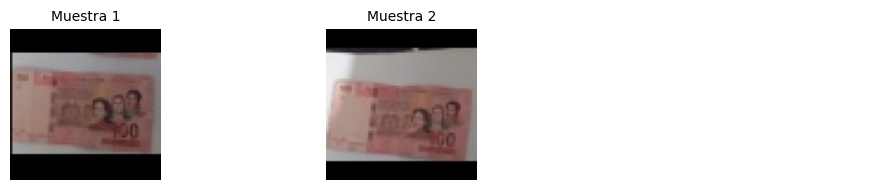

In [31]:
# Celda para visualizar las imágenes reconstruidas desde el array 'data'

import numpy as np
import matplotlib.pyplot as plt

# Verificar si el dataset 'data' ha sido cargado correctamente
if 'data' not in locals() or data.size == 0:
    print("⚠️ ERROR: La variable 'data' no está cargada. Asegúrate de ejecutar el bloque anterior.")
else:
    # Parámetros del dataset
    num_imagenes = data.shape[0]
    tamano_lado = 64
    
    # Mostrar solo las primeras 6 imágenes para no saturar la salida
    num_a_mostrar = min(6, num_imagenes)
    
    print(f"✅ Mostrando las primeras {num_a_mostrar} imágenes reconstruidas (de {num_imagenes} total):")
    
    # Configuración de la galería
    ncols = 3 
    nrows = (num_a_mostrar + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2 * nrows))
    
    # Asegurar que 'axes' sea iterable
    if num_a_mostrar == 1:
        axes = [axes]
    elif nrows > 1 or ncols > 1:
        axes = axes.flatten()

    # Iterar y reconstruir las imágenes
    for i in range(num_a_mostrar):
        # 1. Obtener el vector de píxeles (una fila de 12288 valores)
        vector_plano = data[i]
        
        # 2. Reconstruir la imagen al formato 64x64x3 (alto, ancho, canales)
        # Esto 'desaplana' el vector.
        img_reconstruida = vector_plano.reshape(tamano_lado, tamano_lado, 3)
        
        ax = axes[i]
        
        # Mostrar la imagen
        # Los datos ya están normalizados entre 0 y 1, que es el formato esperado por imshow.
        ax.imshow(img_reconstruida)
        
        # Establecer título
        ax.set_title(f"Muestra {i+1}", fontsize=10)
        
        # Ocultar los ejes
        ax.axis('off')

    # Ocultar subplots vacíos
    for j in range(num_a_mostrar, nrows * ncols):
        if j < len(axes):
            axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# 8. tamaño

In [32]:
# Tu dataset actual NO tiene columna 'label' → no uses drop ni y
X = data # solo los 12288 píxeles
#data.shape
# y no existe → no lo definas

# Normalizar entre 0 y 1

In [33]:
# normalizar los valores de pixeles entre 0 y 1
#X_normalized = X / 255.0 # valor del RGB rojo, azul y amarillo

X_normalized = X

print('Primeros 5 valores de píxel normalizados:', X_normalized[0, :5])

print('Valores minimos y maximos despues de normalizar:')
print('Minimo:', X_normalized.min())
print('Maximo:', X_normalized.max())

Primeros 5 valores de píxel normalizados: [          0           0    0.007843           0           0]
Valores minimos y maximos despues de normalizar:
Minimo: 0.0
Maximo: 0.960784


# Convertir a Tensores

In [34]:
#X_tensor = torch.tensor(X_normalized, dtype=torch.float32).unsqueeze(0)
#print(X_tensor)

# Solución al error de dimensión
X_tensor = torch.tensor(X_normalized, dtype=torch.float32) # <-- ¡Eliminar .unsqueeze(0)!
print('Forma esperada para el modelo:', X_tensor.shape)

Forma esperada para el modelo: torch.Size([2, 12288])


# Modelo de la Red Neuronal

In [35]:
import torch.nn as nn # Asegurarse de tener la librería importada

# Definir los tamaños correctos para el dataset de billetes
input_size = 64*64*3 # 12288 características (píxeles)
output_size = 5     # 5 clases de billetes (0, 1, 2, 3, 4)

# Crear el modelo secuencial (Deep MLP con 8 capas ocultas)
model = nn.Sequential(
    # 8 Capas Ocultas
    nn.Linear(input_size, 8192), # Capa 1
    nn.ReLU(),
    nn.Linear(8192, 4096),       # Capa 2
    nn.ReLU(),
    nn.Linear(4096, 2048),       # Capa 3
    nn.ReLU(),
    nn.Linear(2048, 1024),       # Capa 4
    nn.ReLU(),
    nn.Linear(1024, 512),        # Capa 5
    nn.ReLU(),
    nn.Linear(512, 256),         # Capa 6
    nn.ReLU(),
    nn.Linear(256, 128),         # Capa 7
    nn.ReLU(),
    nn.Linear(128, 64),          # Capa 8
    nn.ReLU(),
    # Capa de Salida
    nn.Linear(64, output_size)   # Capa 9 (5 neuronas para las clases)
).to(torch.device("cpu")) # Mover el modelo a la GPU

model.load_state_dict(torch.load('modelo_clasificacion.pth', map_location='cpu'))  # ← Añade esta línea después

print('Arquitectura del modelo Deep MLP:')
print(model)

Arquitectura del modelo Deep MLP:
Sequential(
  (0): Linear(in_features=12288, out_features=8192, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8192, out_features=4096, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4096, out_features=2048, bias=True)
  (5): ReLU()
  (6): Linear(in_features=2048, out_features=1024, bias=True)
  (7): ReLU()
  (8): Linear(in_features=1024, out_features=512, bias=True)
  (9): ReLU()
  (10): Linear(in_features=512, out_features=256, bias=True)
  (11): ReLU()
  (12): Linear(in_features=256, out_features=128, bias=True)
  (13): ReLU()
  (14): Linear(in_features=128, out_features=64, bias=True)
  (15): ReLU()
  (16): Linear(in_features=64, out_features=5, bias=True)
)


# Modelo de Evaluacion 1

In [36]:
# Inferencia final sobre tus billetes recortados (CORREGIDO)
model.eval()
with torch.no_grad():
    outputs = model(X_tensor)
    _, predicted_tensor = torch.max(outputs, 1) # Usamos un nombre temporal

# 🟢 CORRECCIÓN: Convertir el tensor de predicciones a una lista simple de Python (escalares)
predicted_indices = predicted_tensor.tolist() 


# Mapeo de clases
#valores = [200, 100, 50, 20, 10]
#valores = [10, 20, 50, 100, 200]
valores = [0, 1, 2, 3, 4]
#valores = [4, 3, 2, 1, 0] 

# Mostrar resultados
print("\n=== PREDICCIONES FINALES ===")
archivos = sorted([f for f in os.listdir("imagenes_64x64") if f.endswith(".jpg")])

# Iteramos sobre la lista de índices corregida
for i, pred_index in enumerate(predicted_indices): 
    # pred_index ahora es un entero (int), sin error .item()
    monto = valores[pred_index] 
    
    # Mantenemos el formato de salida
    print(f"{archivos[i]:15} → {monto} Bolivianos (Índice: {pred_index})")

print("=============================")


=== PREDICCIONES FINALES ===
imagen000.jpg   → 3 Bolivianos (Índice: 3)
imagen001.jpg   → 3 Bolivianos (Índice: 3)


# Modelo e Evaluacion 2

In [37]:
import torch
import os
# Asegúrate de que X_tensor y model están definidos y cargados

# Inferencia final sobre tus billetes recortados
model.eval()
with torch.no_grad():
    outputs = model(X_tensor)
    _, predicted = torch.max(outputs, 1) # 'predicted' es un tensor de índices [0, 1, 2, 3, 4]

# --- El array 'valores' ha sido eliminado ---
# Los siguientes arrays fueron eliminados, ya que solicitaste no usarlos para la predicción:
# valores = [200, 100, 50, 20, 10]
# valores = [10, 20, 50, 100, 200]
valores = [0, 1, 2, 3, 4]
# valores = [4, 3, 2, 1, 0]


# Mostrar resultados
print("\n=== RESULTADO FINAL ===")
archivos = sorted([f for f in os.listdir("imagenes_64x64") if f.endswith(".jpg")])

for i, pred in enumerate(predicted):
    
    # CORRECCIÓN: Usar pred.item() para obtener el valor escalar (el índice de clase)
    clase_predicha = pred.item() 
    
    print(f"{archivos[i]:15} → CLASE {clase_predicha}")

print("========================")


=== RESULTADO FINAL ===
imagen000.jpg   → CLASE 3
imagen001.jpg   → CLASE 3


# Modelo de Evaluacion

In [38]:
import torch
import os
# Asegúrate de que las variables 'model' y 'X_tensor' están cargadas en este punto.

# Inferencia final sobre tus billetes recortados
# 1. Poner el modelo en modo de evaluación
model.eval()

# 2. Desactivar el cálculo de gradientes
with torch.no_grad():
    # 3. Ejecutar el modelo para obtener los logits (puntuaciones sin softmax)
    outputs = model(X_tensor)
    
# Mostrar el tensor de resultado completo
print("\n=== TENSOR DE RESULTADO COMPLETO (LOGITS/SCORES) ===")
print(outputs)
print(f"Forma del Tensor: {outputs.shape}") # Ejemplo: torch.Size([4, 5]) si hay 4 imágenes y 5 clases
print("=====================================================")


# Código para obtener las predicciones finales (opcional)
_, predicted = torch.max(outputs, 1)

# Mostrar las predicciones finales
print("\n=== ÍNDICES DE CLASE PREDICHOS ===")
archivos = sorted([f for f in os.listdir("imagenes_64x64") if f.endswith(".jpg")])

for i, pred in enumerate(predicted):
    clase_predicha = pred.item() 
    print(f"{archivos[i]:15} → CLASE {clase_predicha}")

print("========================")


=== TENSOR DE RESULTADO COMPLETO (LOGITS/SCORES) ===
tensor([[-45.4150,  87.0520, -19.9225,  89.8458,  47.7331],
        [-52.3346,  95.2603, -11.9421, 119.2609,  53.9893]])
Forma del Tensor: torch.Size([2, 5])

=== ÍNDICES DE CLASE PREDICHOS ===
imagen000.jpg   → CLASE 3
imagen001.jpg   → CLASE 3
